In [33]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as wg
from IPython.display import display
import scipy.special

# Analysis of Error-Correcting Codes in Telecommunications
## Topic: Linear Algebra and Probabilistic Modeling of Hamming (7,4)

---

### Abstract
This project explores how mathematical methods can be used to maintain data integrity in noisy communication channels. While simple error detection only indicates that corruption has occurred, Error-Correcting Codes (ECC) can actually identify and repair errors. In this project, the Hamming (7,4) algorithm is implemented in Python to demonstrate how matrix operations over finite fields can be used to recover corrupted information.

---

### Table of Contents
1. [Description of the Error Control Problem](#section1)  
    1.1. [Noise and Data Integrity](#section1_1)  
    &nbsp;&nbsp;&nbsp;&nbsp;1.1.1. [The Binary Symmetric Channel (BSC) Model](#section1_1_1)  
    &nbsp;&nbsp;&nbsp;&nbsp;1.1.2. [Bit-Flip Probability and Signal Interference](#section1_1_2)  
    1.2. [Error Detection vs. Error Correction](#section1_2)  
    &nbsp;&nbsp;&nbsp;&nbsp;1.2.1. [The Concept of Redundancy](#section1_2_1)  
    &nbsp;&nbsp;&nbsp;&nbsp;1.2.2. [Limits of Detection: The Parity Bit Approach](#section1_2_2)  
    &nbsp;&nbsp;&nbsp;&nbsp;1.2.3. [The Geometry of Error Correction: Hamming Distance](#section1_2_3)
    &nbsp;&nbsp;&nbsp;&nbsp;1.2.4. [System Trade-offs Between Detection and Correction](#section1_2_4)
2. [Mathematical Foundations](#section2)  
    2.1. [Linear Algebra in $GF(2)$](#section2_1)  
    &nbsp;&nbsp;&nbsp;&nbsp;2.1.1. [Binary Arithmetic and XOR Operations](#section2_1_1)  
    &nbsp;&nbsp;&nbsp;&nbsp;2.1.2. [Vector Spaces over Finite Fields](#section2_1_2)  
    2.2. [The Generator Matrix $G$](#section2_2)  
    &nbsp;&nbsp;&nbsp;&nbsp;2.2.1. [Systematic Encoding Form](#section2_2_1)  
    &nbsp;&nbsp;&nbsp;&nbsp;2.2.2. [Mapping 4-bit Messages to 7-bit Codewords](#section2_2_2)  
    2.3. [The Parity-Check Matrix $H$](#section2_3)  
    &nbsp;&nbsp;&nbsp;&nbsp;2.3.1. [Defining the Null Space](#section2_3_1)  
    &nbsp;&nbsp;&nbsp;&nbsp;2.3.2. [Syndrome Calculation Logic](#section2_3_2)  
3. [Implementation and Simulation](#section3)  
    3.1. [Encoding Algorithm](#section3_1)  
    3.2. [The Noisy Channel Model](#section3_2)  
    3.3. [Decoding and Correction](#section3_3)  
    3.4. [Interactive Simulation: Error Correction Performance](#section_3_4)  
    &nbsp;&nbsp;&nbsp;&nbsp;3.4.1 [Simulation Observations & Analysis](#section3_4_1)  
5. [Modern Aproach: From Hamming to Reed-Solomon and LDPC](#section4)  
    4.1. [Beyond Single-Bit Errors: Reed-Solomon](#section4_1)  
    4.2. [Near the Shannon Limit: LDPC and Turbo Codes](#section4_2)  
    4.3  [Simulation of Higher-Order Error Correction](#section4_3)  
    &nbsp;&nbsp;&nbsp;&nbsp;4.3.1 [Connecting Math to Code](#section4_3_1)  
7. [Performance Analysis: The Efficiency–Resilience Trade-off](#section5)
    5.1. [The "Success Waterfall"](#section5_1)  
    5.2. [Efficiency vs. Protection (The Overhead)](#section5_2)  
    5.3  [Final Interpretation](#section5_3)  
9. [Conclusion](#conclusion)



<a id="section1"></a>
# 1. Description of the Error Control Problem
    
In the world of informatics, "noise" is like static on a radio or a smudge on a letter. When we send a message (like 1011), the universe is messy. Heat, magnetism, or even a microwave oven can "smudge" our data.Richard Hamming’s motivation wasn't just theoretical "noise"—it was a very personal frustration with a computer that kept quitting on him.
In the late 1940s, Hamming worked at Bell Labs using a mechanical computer that ran on punch cards. He would often set his programs to run over the weekend, but if a single bit of data was "smudged" by a hardware glitch, the machine would simply stop and move on to the next person's job.
He’d arrive on Monday morning only to find his work had failed hours after he left. Frustrated by the wasted time, he famously realized: "If the machine can detect an error, why can't it locate the position of the error and correct it?" He developed the code so the computer could fix its own mistakes and keep working without him.

---

<a id="section1_1"></a>
## 1.1. Noise and Data Integrity
Data integrity is the promise that what arrives is exactly what was sent—nothing more, nothing less. Consider transmitting a single bit, $x$, across a communication channel.. On the other end, the receiver reads a bit $y$. If everything goes well, the story ends simply: $y = x$. The bit that left the sender is the same bit that reaches the receiver.

But sometimes the journey isn’t perfect. Noise or interference during transmission may change the message. In that case, the receiver might get a different value, so $y \neq x$. When this happens, the integrity of the message is broken—the information that arrived is no longer the same as the information that was originally sent.

In essence, data integrity is about protecting the transmission from $x$ to $y$, ensuring that the message remains unchanged from the moment it leaves the sender to the moment it reaches the receiver.
    
---

<a id="section1_1_1"></a>
### 1.1.1 The Binary Symmetric Channel (BSC) Model
The Binary Symmetric Channel (BSC) is a simple and widely used model in information theory for describing how errors can occur during data transmission. The idea is to imagine a communication channel that sometimes makes mistakes while sending bits.

When a bit is transmitted, there is a fixed probability $p$ that the bit will be flipped during transmission. This means that a $0$ may become a $1$, or a $1$ may become a $0$ by the time it reaches the receiver.

The channel is called *binary* because it deals only with bits (0s and 1s), and it is called *symmetric* because the probability of flipping is the same in both directions. In other words, the probability that $0 \rightarrow 1$ is $p$, and the probability that $1 \rightarrow 0$ is also $p$.

If the bit is not flipped, which happens with probability $1 - p$, the receiver gets exactly the same bit that was sent.

This model is useful because it captures the idea that communication channels are not perfect—sometimes errors occur—but those errors can still be studied and handled in a structured way.

This is the simplest way to mathematically model a "messy" communication line, such as a noisy phone connection. The idea is that during transmission, each bit has a probability $p$ of being flipped.

If we send a $0$, the receiver gets a $1$ with probability $p$.  
If we send a $1$, the receiver gets a $0$ with probability $p$.

Because the probability of flipping is the same in both directions, the channel is called symmetric.

We represent this behavior mathematically as:

$$
P(y \mid x) =
\begin{cases}
1 - p & \text{if } y = x \\
p & \text{if } y \ne x
\end{cases}
$$

This expression describes the probability that the receiver observes a bit $y$ given that the sender transmitted the bit $x$.

---

### 1.1.2 Bit-Flip Probability and Signal Interference

Signal interference occurs when external energy "confuses" the receiver. Imagine a row of light switches. If someone shakes the wall, a switch might accidentally flip from OFF ($0$) to ON ($1$), or from ON ($1$) to OFF ($0$).

In a communication channel, interference such as electrical noise, electromagnetic signals, or hardware imperfections can cause the same type of behavior. As a result, a transmitted bit may randomly change during transmission.

To simulate this process, we model the bit flip using probability. Let $x$ be the transmitted bit and $y$ the received bit. Each bit has a probability $p$ of flipping due to interference.

Mathematically, we can represent this as:

$$
y =
\begin{cases}
x & \text{with probability } 1 - p \\
1 - x & \text{with probability } p
\end{cases}
$$

In our simulation, we use a random number generator to represent this randomness. If a generated random number is less than $p$, the bit flips. Otherwise, the bit remains unchanged.

$$
y =
\begin{cases}
1 - x & \text{if } r < p \\
x & \text{if } r \ge p
\end{cases}
$$

where $r \sim U(0,1)$ is a random number drawn from a uniform distribution between $0$ and $1$.

---

## 1.2 Error Detection vs. Error Correction

When sending data over a communication channel, errors can occur due to noise or interference. To handle these errors, systems use either error detection or error correction. 

- Error detection identifies when an error has occurred. The receiver can tell that the data is corrupted, but it may not know how to fix it.  
- Error correction goes further by allowing the receiver to reconstruct the original message even when errors happen.

Understanding both approaches is fundamental for building reliable communication systems.

---

### 1.2.1 The Concept of Redundancy

In information theory, redundancy is the "extra" information added to a message that allows it to resist noise. Without redundancy, every possible combination of bits is a valid message; therefore, if one bit flips, the receiver has no way of knowing it wasn't the intended message.By expanding 4 bits into 7, we create a Constraint. The Hamming (7,4) code uses a "Code Rate" ($R$) to measure efficiency:

$$
R = \frac{k}{n} = \frac{4}{7} \approx 0.57
$$

The Critical Weakness:
Ambiguity: While the receiver knows a flip occurred (because the sum becomes odd), they cannot locate it. It is like an alarm that says "There is a fire" but doesn't tell you which room.
Invisible Errors: If two bits flip, the parity becomes even again ($1+1=0$ in binary). The receiver is completely "blind" to this error. This highlights the need for more complex codes like Hamming, which use multiple parity bits to "triangulate" the error.

---

### 1.2.2 Limits of Detection: The Parity Bit Approach

The simplest form of redundancy is the Single Parity Check (SPC). This method adds a bit $p$ such that the total number of $1$s is even. Mathematically, this is expressed as a summation over $GF(2)$:
$$
\sum_{i=1}^{n} x_i \equiv 0 \pmod 2
$$

If a single bit flips during transmission, the parity becomes odd, signaling that an error occurred. However, this approach cannot identify which bit is wrong, so the receiver can only request the message to be resent.

---

### 1.2.3 The Geometry of Error Correction: Hamming Distance
Error correction can be visualized geometrically. Imagine that every 7-bit binary string represents a point in a 7-dimensional space In this space, most points correspond to invalid or illegal codewords, while only a small subset represent valid encoded messages.

To measure how different two binary strings are, we use the Hamming distance.

The Hamming distance \( d(x, y) \) between two binary strings \( x \) and \( y \) is defined as the number of positions where the bits differ:

$$
d(x,y) = \sum_{i=1}^{n} \mathbf{1}(x_i \ne y_i)
$$

where \( \mathbf{1}(\cdot) \) is an indicator function that equals 1 when the condition is true and 0 otherwise.

#### Example

Let

$$
x = [1,0,1,1,0,0,0]
$$

$$
y = [1,1,1,1,0,0,1]
$$

Comparing the bits position by position, the strings differ in the 2nd and 7th positions. Therefore,

$$
d(x,y) = 2
$$



#### The Distance-3 Rule

The Hamming (7,4) code is designed so that every valid codeword is at least distance 3 away from any other valid codeword.

This property allows the receiver to detect and correct errors:

- If one bit flips the received message moves to a point that is distance 1 from the correct codeword.
- However, it remains distance 2 or more away from every other valid codeword

Because of this separation, the receiver can simply choose the closest valid codeword to the received message.

This decoding strategy is known as Maximum Likelihood Decoding.


---

## 1.2.4 System Trade-offs Between Detection and Correction

While error detection and error correction both rely on redundancy, their system-level behavior differs significantly. The choice between them depends on the communication environment, latency constraints, and computational resources.

Error detection mechanisms such as parity checking are typically combined with Automatic Repeat Request (ARQ) protocols, where corrupted packets are retransmitted. In contrast, error correction techniques such as Hamming codes use Forward Error Correction (FEC) to repair errors locally without requiring retransmission.

This leads to important differences in reliability, bandwidth efficiency, and delay.

---

### Bandwidth Efficiency

If a message contains \(k\) data bits and \(r\) redundant bits, the transmitted codeword length becomes

$$
n = k + r
$$


The code rate measures how efficiently the channel is used:

$$
R = \frac{k}{n}
$$
Example calculations:

Parity check (7 data bits + 1 parity bit):

$$
R_{parity} = \frac{7}{8} = 0.875
$$

Hamming (7,4):

$$
R_{Hamming} = \frac{4}{7} \approx 0.57
$$

This shows that error detection schemes typically achieve higher transmission efficiency, while error correction sacrifices efficiency to gain resilience.

---

### Reliability Under Bit Errors

Let the bit error probability of the channel be \(p\).

For a block of \(n\) bits, the probability that the block is received without error is

$$
P_{correct} = (1-p)^n
$$

The probability that exactly one bit flips is

$$
P_{1} = n p (1-p)^{n-1}
$$

This value is important because Hamming codes can correct exactly one bit error.

Therefore the probability that a Hamming code successfully reconstructs the message is approximately

$$
P_{success} = (1-p)^n + n p (1-p)^{n-1}
$$

Parity checking cannot repair the message; it can only detect errors and request retransmission.

---

### Latency Considerations

In ARQ-based systems, retransmissions increase the expected transmission time.

If the packet error probability is \(P_e\), the expected number of transmissions becomes

$$
E[T] = \frac{1}{1 - P_e}
$$

The expected delay is therefore

$$
D_{ARQ} = \frac{D_0}{1 - P_e}
$$

where \(D_0\) represents the base transmission delay.

Forward Error Correction performs decoding locally, giving

$$
D_{FEC} \approx D_0 + D_{decode}
$$

Since decoding hardware is fast, \(D_{decode}\) is typically very small.

---

### Extended Comparison

| Feature | Error Detection (Parity) | Error Correction (Hamming) |
|--------|--------|--------|
| Action | Detects that corruption occurred | Detects and repairs a single-bit error |
| Response Mechanism | ARQ – retransmission required | FEC – correction at receiver |
| Code Rate | High efficiency (≈0.875) | Lower efficiency (≈0.57) |
| Error Handling | Detects odd-numbered bit flips | Corrects 1-bit errors, detects 2-bit errors |
| Latency Model | \(D_{ARQ} = \frac{D_0}{1-P_e}\) | \(D_{FEC} \approx D_0 + D_{decode}\) |
| Computational Cost | Very low | Moderate (syndrome calculation) |
| Typical Applications | Ethernet frames, storage checks | Satellite links, deep-space probes, ECC memory |

---

### Practical Interpretation

In low-noise environments, error detection combined with retransmission is usually preferred because it preserves bandwidth efficiency. However, in channels where retransmission is expensive or impossible—such as deep-space communication—forward error correction becomes essential.

This trade-off between bandwidth efficiency, computational complexity, and latency is one of the central design decisions in communication systems.



<a id="section2"></a>

## 2. Mathematical Foundations

<a id="section2_1"></a>

### 2.1 Linear Algebra in $GF(2)$

Standard linear algebra operates over real numbers ($\mathbb{R}$), but digital systems require a discrete structure. We utilize Galois Field 2 ($GF(2)$), a finite field consisting only of the elements $\{0, 1\}$.

### 2.1.1. Binary Arithmetic and XOR Operations
In $GF(2)$, all operations are performed modulo 2. This means addition is equivalent to the logical XOR operation, and multiplication is equivalent to the logical AND.Addition ($+$): $1+1=0, 1+0=1, 0+0=0$Multiplication ($\cdot$): $1 \cdot 1 = 1, 1 \cdot 0 = 0, 0 \cdot 0 = 0$

This is equivalent to the XOR operation. In GF(2), adding 1 to 1 returns 0, similar to a 2-hour clock.
<p align="center">
  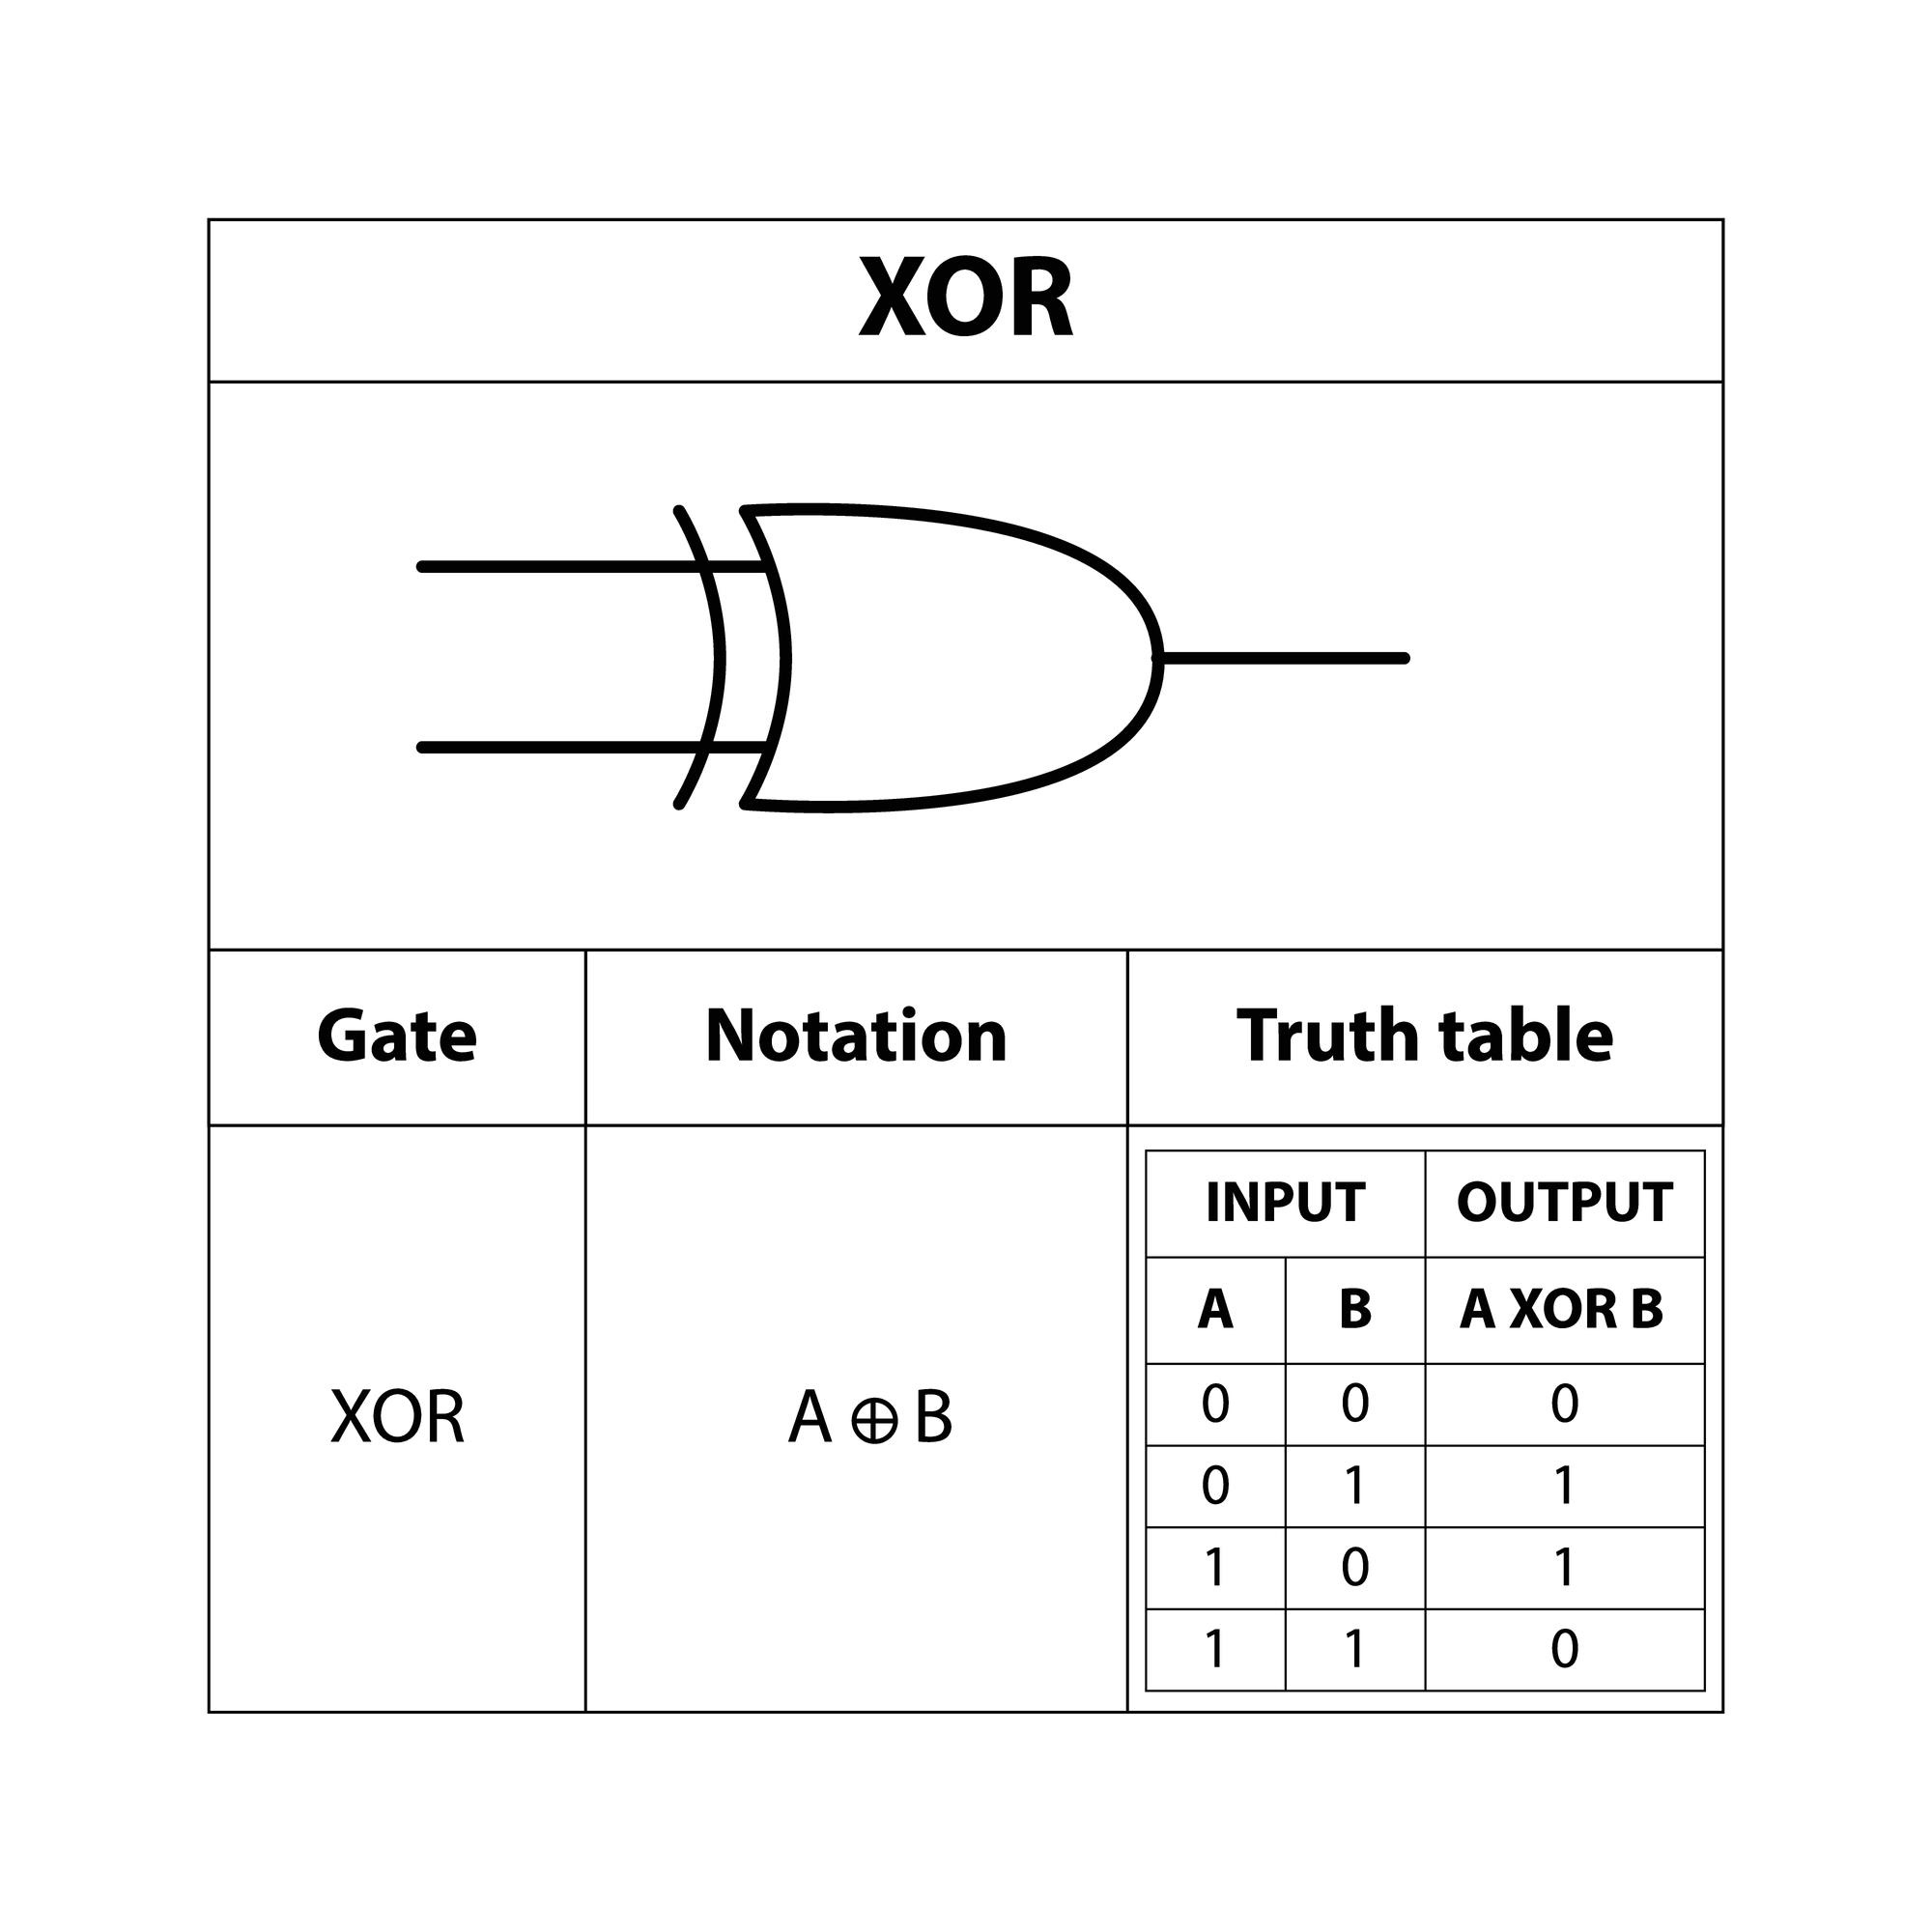
</p>

Figure 1: XOR truth table demonstrating bit flipping in GF(2).  
This table shows the result of XOR operations between bits, which is used in our simulation of a noisy channel. For example, $1 \oplus 1 = 0$ and $0 \oplus 1 = 1$, which corresponds to flipping bits when errors occur.


---

2.1.2. Vector Spaces over Finite FieldsWe treat our 4-bit message as a vector $\mathbf{u}$ in a 4-dimensional vector space $V = GF(2)^4$. Encoding is the process of mapping this vector into a higher 7-dimensional space $W = GF(2)^7$. The "magic" of Hamming codes lies in choosing a subspace of $W$ where every vector is far apart from the others.

---


### 2.2.1 Systematic Encoding Form

For a systematic Hamming (7,4) code, the generator matrix $G$ has the structure

$$
G = [I_k \mid P]
$$

where:

- $I_k$ is the $k \times k$ identity matrix  
- $P$ is the parity generation matrix

This structure is efficient because the original message bits appear directly in the encoded output, followed by the parity bits.

For the Hamming (7,4) code, the generator matrix is:

$$
G =
\begin{pmatrix}
1 & 0 & 0 & 0 & 1 & 1 & 0 \\
0 & 1 & 0 & 0 & 1 & 0 & 1 \\
0 & 0 & 1 & 0 & 0 & 1 & 1 \\
0 & 0 & 0 & 1 & 1 & 1 & 1
\end{pmatrix}
$$

---

### 2.2.2 Mapping 4-bit Messages to 7-bit Codewords

This structure means that:

- The first 4 bits of the codeword correspond to the original message.
- The last 3 bits are parity bits calculated from the data bits.

By mapping a 4-bit message into a 7-bit space, redundancy is introduced. This redundancy creates a safety margin that allows the system to detect and correct errors caused by noise during transmission.

---

## 2.3 The Parity-Check Matrix ($H$)

The receiver uses the Parity-Check Matrix $H$ to determine whether the received message is valid.

---

### 2.3.1 Defining the Null Space

In linear algebra, the null space of a matrix consists of all vectors that produce zero when multiplied by that matrix.

A key property of Hamming codes is that all valid codewords belong to the null space of the parity-check matrix. Mathematically:

$$
H \cdot \mathbf{c}^T = \mathbf{0} \pmod{2}
$$

If the result is not the zero vector, the received vector no longer belongs to the valid code space.

---

### 2.3.2 Syndrome Calculation Logic

If $\mathbf{r}$ is the received 7-bit vector, the receiver computes the syndrome:

$$
\mathbf{s} = \mathbf{r} \cdot H^T \pmod{2}
$$

In a perfect transmission:

$$
\mathbf{s} = \mathbf{0}
$$

For the Hamming (7,4) code, the parity-check matrix is:

$$
H =
\begin{pmatrix}
1 & 1 & 0 & 1 & 1 & 0 & 0 \\
1 & 0 & 1 & 1 & 0 & 1 & 0 \\
0 & 1 & 1 & 1 & 0 & 0 & 1
\end{pmatrix}
$$

If

$$
\mathbf{s} \neq \mathbf{0}
$$

then an error has occurred.

Because each column of $H$ is unique, the syndrome $\mathbf{s}$ acts like a fingerprint of the error. If only one bit is flipped, the syndrome will match the column of $H$ corresponding to that bit's position.

This property allows the receiver to locate and correct the corrupted bit immediately.


<a id="section3"></a>

## 3. Implementation and Simulation

In this section, we implement the Hamming (7,4) code using Python and the `numpy` library. The implementation follows the systematic approach, meaning that the original data bits remain unchanged while the parity bits are added to form the final encoded message.

### 3.1 Encoding Algorithm

The encoding process is based on the Generator Matrix \( G \).  
Mathematically, the encoded codeword is obtained by performing a vector–matrix multiplication over the finite field \( GF(2) \).

In practice, this means that the binary data vector is multiplied by the generator matrix, and the result is computed modulo 2 so that all values remain binary (either 0 or 1).

In Python, this operation can be implemented using NumPy’s dot product, followed by a modulo 2 operation to ensure that the output stays within the binary set \( \{0,1\} \).


In [34]:
G = np.array([
    [1, 0, 0, 0, 1, 1, 0],
    [0, 1, 0, 0, 1, 0, 1],
    [0, 0, 1, 0, 0, 1, 1],
    [0, 0, 0, 1, 1, 1, 1]
])

def encode(message):
    return np.dot(message, G) % 2

msg = np.array([1, 0, 1, 1])
codeword = encode(msg)
print("Original message:", msg)
print("Encoded codeword:", codeword)

Original message: [1 0 1 1]
Encoded codeword: [1 0 1 1 0 1 0]


### 3.2 The Noisy Channel Model

We can simulate a noisy channel where each bit has a probability $p$ of flipping using Python. This represents the Binary Symmetric Channel (BSC) model. The example has a high probability just for the testing purposes  so that bit flips occur more frequently during the simulation.

In [35]:

def binary_symmetric_channel(data, p):
    noise_mask = np.random.rand(len(data)) < p
    noisy_data = (data + noise_mask.astype(int)) % 2
    return noisy_data

original = np.array([1, 1, 0, 0, 1, 0, 1])
noisy = binary_symmetric_channel(original, p=0.4)

print(f"Original: {original}")
print(f"Noisy:    {noisy}")

Original: [1 1 0 0 1 0 1]
Noisy:    [1 0 0 0 0 1 0]


### 3.3. Decoding and Correction Logic
The decoder acts as the "Controller" of our system. It uses the Parity-Check Matrix ($H$) to calculate a Syndrome, which serves as a unique "fingerprint" identifying the location of a flipped bit.While the syndrome detects the error, the Correction Logic maps that syndrome to a specific bit index (0-6). By applying a bitwise XOR at that index, the system "self-heals," reverting the corrupted bit to its original state. This allows for seamless data recovery without the need for re-transmission.

In [36]:
H = np.array([
    [1, 1, 0, 1, 1, 0, 0],
    [1, 0, 1, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 0, 1]
])

def get_syndrome(received_vector):
    return np.dot(received_vector, H.T) % 2

def correct_bit(received_vector, syndrome):
    syndrome_to_index = {
        (1, 1, 0): 0, (1, 0, 1): 1, (0, 1, 1): 2, (1, 1, 1): 3,
        (1, 0, 0): 4, (0, 1, 0): 5, (0, 0, 1): 6
    }
    s_tuple = tuple(syndrome.astype(int))
    corrected = received_vector.copy()
    
    if np.any(syndrome):
        idx = syndrome_to_index.get(s_tuple)
        if idx is not None:
            corrected[idx] = (corrected[idx] + 1) % 2
            print(f"Correction Applied: Flipped bit at index {idx}")
        else:
            print("Syndrome detected but index not found (Likely multiple errors).")
    return corrected

msg = np.array([1, 0, 1, 1])
codeword = encode(msg) 
received = codeword.copy()
received[2] ^= 1    

syndrome = get_syndrome(received)
final_output = correct_bit(received, syndrome)

print("Original Message:       ", msg)
print("Recovered Message Bits: ", final_output[:4])
print("Success:                ", np.array_equal(msg, final_output[:4]))

Correction Applied: Flipped bit at index 2
Original Message:        [1 0 1 1]
Recovered Message Bits:  [1 0 1 1]
Success:                 True


### 3.4 Interactive Simulation: Error Correction Performance
This section presents an interactive Monte Carlo simulation designed to visualize the real-world effectiveness of the Hamming (7,4) code. By adjusting the noise probability $p$ via a slider, we can observe the system's "Self-Healing" threshold in real-time across hundreds of random trials.The simulation compares a raw, unprotected data stream against a Hamming-protected stream. This visualization makes it mathematically evident that while the code effectively eliminates single-bit errors at low noise levels, its performance begins to degrade once the probability of multiple-bit errors—which exceed the code's minimum distance ($d_{min}=3$)—becomes significant. This transition represents the physical limit of the (7,4) block code.

In [37]:
def run_hamming_simulation(p_noise, N=10):
    unprotected_failures = 0
    hamming_failures = 0
    
    syndrome_to_index = {
        (1, 1, 0): 0, (1, 0, 1): 1, (0, 1, 1): 2, (1, 1, 1): 3,
        (1, 0, 0): 4, (0, 1, 0): 5, (0, 0, 1): 6
    }

    print(f"{'TRIAL':<6} | {'ORIGINAL':<10} | {'RECEIVED':<15} | {'SYNDROME':<10} | {'ACTION / CORRECTION'}")
    print("-" * 80)

    for i in range(N):
        msg = np.random.randint(0, 2, 4)
        encoded = encode(msg)
        noisy = binary_symmetric_channel(encoded, p_noise)
        
        if not np.array_equal(encoded, noisy):
            unprotected_failures += 1
            
        syndrome = get_syndrome(noisy)
        s_tuple = tuple(syndrome.astype(int))
        corrected = noisy.copy()
        
        action = "✅ Clean"
        if np.any(syndrome):
            idx = syndrome_to_index.get(s_tuple)
            if idx is not None:
                corrected[idx] = (corrected[idx] + 1) % 2
                action = f"🔧 Fixed Bit {idx}"
            else:
                action = "❌ Multi-Error (Fail)"

        recovered_msg = corrected[:4]
        if not np.array_equal(msg, recovered_msg):
            hamming_failures += 1

        status_icon = "✔️" if np.array_equal(msg, recovered_msg) else "❌"
        print(f"#{i+1:<5} | {msg} | {noisy} | {str(s_tuple):<10} | {action:<20} {status_icon}")

    plt.figure(figsize=(8, 3))
    plt.barh(['Raw Error', 'Hamming Fixed'], [unprotected_failures, hamming_failures], color=['#e74c3c', '#2ecc71'])
    plt.title(f"Results for {N} Trials")
    plt.xlabel("Total Failures")
    plt.show()

p_slider = wg.FloatSlider(value=0.1, min=0.0, max=0.5, step=0.05, description='Noise')
n_slider = wg.IntSlider(value=10, min=1, max=2500, step=1, description='Trials')

ui = wg.VBox([p_slider, n_slider])
out = wg.interactive_output(run_hamming_simulation, {'p_noise': p_slider, 'N': n_slider})
display(ui, out);

Output()

### 3.4.1 Observations from the Simulation

After running the Monte Carlo simulation with different noise levels, we can start to see how the Hamming (7,4) code behaves in practice. As someone just beginning to explore error-correcting codes, these results help make the theory much clearer. A few key observations stand out.

#### 1. The “Self-Healing” Threshold

At very low noise levels ($p < 0.05$), the simulation shows that almost all errors disappear after decoding.  
When looking at the trial output, we can see the syndrome calculation identifying single-bit errors and correcting them immediately.

This makes the system feel almost self-healing: a bit flips during transmission, but the decoder detects where it happened and fixes it before the data is delivered.

This result confirms an important idea: Hamming (7,4) works very well when errors are rare and occur independently.

#### 2. The Geometric Limit ($d_{min} = 3$)

As we increase the noise probability using the slider, we start to notice that the “Hamming Protected” failure counter slowly increases.

Looking more closely at the printed output, these failures usually happen when two or more bits flip in the same 7-bit codeword.

This behavior matches the theoretical limit of the code. The minimum Hamming distance is

$$
d_{min} = 3
$$

Because of this distance, the code can guarantee correction of only one error in each block.  
If two bits flip, the decoder may misinterpret the syndrome and produce an incorrect correction.

Seeing this happen in the simulation helps illustrate the real limitation of the code's correction capability.

#### 3. The Cost of Reliability

Another thing that becomes clear from the simulation is the trade-off between reliability and efficiency.

To protect the data, the Hamming (7,4) code adds 3 parity bits for every 4 data bits.  
This means the code rate is

$$
R = \frac{4}{7} \approx 0.57
$$

In practical terms, this means that only about 57% of the transmitted bits carry actual data, while the rest are used for error protection.

In a real communication system, this translates to giving up roughly 43% of the bandwidth in order to make the transmission more reliable.  
It might feel like a large cost, but in noisy environments this extra redundancy is often what makes reliable communication possible.


<a id="section4"></a>

## 4. Modern Approach: From Hamming to Reed–Solomon and LDPC

The Hamming (7,4) code was one of the first practical examples of error-correcting codes. It demonstrated that it is possible not only to *detect* transmission errors but also to *correct* them automatically.

In the Hamming code, a 4-bit data vector

$$
\mathbf{d} = [d_1, d_2, d_3, d_4]
$$

is encoded into a 7-bit codeword

$$
\mathbf{c} = \mathbf{d}G
$$

where $G$ is the generator matrix, and all operations are performed over the binary field $GF(2)$.

$$
G =
\begin{bmatrix}
1 & 0 & 0 & 0 & 1 & 1 & 0 \\
0 & 1 & 0 & 0 & 1 & 0 & 1 \\
0 & 0 & 1 & 0 & 0 & 1 & 1 \\
0 & 0 & 0 & 1 & 1 & 1 & 1
\end{bmatrix}
$$

This structure allows the decoder to detect and correct one bit error, since the minimum Hamming distance is

$$
d_{min} = 3
$$

and the theoretical error correction capability is

$$
t = \left\lfloor \frac{d_{min}-1}{2} \right\rfloor = 1
$$

However, this model assumes that errors are rare and independent. As communication technology developed—especially in satellites, storage devices, and wireless networks—it became clear that real channels often produce clusters of errors, not just single flipped bits.

Because of this, engineers developed more advanced error-correcting codes.

---

### 4.1 Beyond Single-Bit Errors: Reed–Solomon Codes

One of the biggest limitations of the Hamming code is that it struggles with burst errors. A burst error occurs when several bits in a row are corrupted.

This happens frequently in real systems:

- A scratched CD or DVD may damage a whole block of stored bits  
- A QR code may be partially covered or dirty  
- Satellite communication may experience short bursts of atmospheric noise  

Instead of isolated bit flips, the system sees blocks of corrupted data.

The key idea behind Reed–Solomon (RS) codes is to work with symbols instead of individual bits.

A message is represented as a polynomial over a finite field:

$$
m(x) = m_0 + m_1x + m_2x^2 + \dots + m_kx^k
$$

The encoded codeword is generated by evaluating this polynomial at multiple points:

$$
c_i = m(\alpha_i)
$$

where $\alpha_i$ are elements of a finite field such as $GF(2^8)$.

This means each symbol typically represents 8 bits (one byte).

The error-correction capability of a Reed–Solomon code depends on the number of parity symbols:

$$
t = \frac{n - k}{2}
$$

where:

- $n$ = total number of symbols  
- $k$ = number of data symbols  
- $t$ = number of correctable symbol errors  

The important part is that multiple bit errors inside one symbol still count as a single symbol error. Because of this, Reed–Solomon codes are very effective against localized bursts of damage.

This is why they are used in technologies such as:

- QR codes
- CDs and DVDs
- Deep-space communication

Even when part of the data is physically damaged, the original information can still be reconstructed.

---

### 4.2 Approaching the Shannon Limit: LDPC and Turbo Codes

In 1948, Claude Shannon introduced the concept of channel capacity, which defines the maximum data rate that can be transmitted over a noisy channel while still allowing reliable communication.

For a channel with bandwidth $B$ and signal-to-noise ratio $S/N$, the capacity is

$$
C = B \log_2(1 + S/N)
$$

This theoretical limit is often called the Shannon Limit.

For many decades, engineers could not design practical error-correcting codes that approached this boundary.

That changed with the development of Turbo Codes and the rediscovery of LDPC (Low-Density Parity-Check) codes.

---

### LDPC Codes

LDPC codes use a large sparse parity-check matrix $H$:

$$
H\mathbf{c}^T = 0
$$

where:

- $H$ is a sparse matrix  
- $\mathbf{c}$ is the transmitted codeword  

Unlike the small matrices used in Hamming codes, LDPC matrices can contain thousands of rows and columns.

Decoding is performed using an iterative algorithm called *belief propagation*, where nodes exchange probability estimates about the most likely value of each bit.

With each iteration, the estimate improves until the decoder converges on the most probable codeword.

---

### Turbo Codes

Turbo codes were another major breakthrough, particularly for mobile communication systems.

They use two recursive encoders and an interleaver to create multiple redundant representations of the same data.

The encoded sequence can be represented as

$$
\mathbf{c} = (\mathbf{u}, \mathbf{p}_1, \mathbf{p}_2)
$$

where:

- $\mathbf{u}$ is the original data sequence  
- $\mathbf{p}_1$ and $\mathbf{p}_2$ are parity sequences generated by two encoders  

The decoder repeatedly exchanges information between two decoding stages, gradually refining the estimate of the transmitted data.

---

### Current Standards

Today, LDPC codes are widely used in modern communication systems, including:

- 5G New Radio (NR)
- Wi-Fi 6
- High-speed satellite communication

What makes them remarkable is that their performance comes very close to the Shannon limit, sometimes within a fraction of a decibel.

In practical terms, this allows modern systems to transmit gigabits of data per second with extremely low error rates, even over noisy channels.

---

From a learning perspective, seeing the progression from Hamming codes → Reed–Solomon → LDPC and Turbo codes helps illustrate how the field of information theory has evolved. Each generation of codes was developed to overcome the limitations of the previous one, enabling faster and more reliable communication systems.


<a id="section4_3"></a>

### 4.3 Simulation of Higher-Order Error Correction

After looking at more modern error-correcting codes like Reed–Solomon and LDPC, it becomes clear that one of the key differences from the Hamming code is the size of the block that is being encoded. Larger blocks usually allow the code to detect and correct more errors, although the mathematics behind it becomes more complex.

To get a basic idea of why modern systems (such as 5G) use larger block lengths, we created a small simulation that represents a more “modern-style” block code. The goal here is not to fully implement a real industrial code, but rather to observe how increasing the block size can improve error correction.

In the earlier sections, we used the Hamming (7,4) code. This code works with a block of 7 bits and can correct at most one bit error in each block.

In this simulation, we instead look at a larger block of 15 bits. In theory, a code with these parameters could correct up to two bit errors within the same block. This means that even if two bits are corrupted during transmission, the decoder would still be able to recover the original message.

From a learning perspective, this experiment helps illustrate an important idea in coding theory:  
increasing the block length often increases the error-correction capability, although it also increases the complexity of the encoding and decoding process.

At this stage, the goal of the simulation is mainly to visualize how these larger blocks behave under noise and to compare their performance with the simpler Hamming (7,4) code used earlier.


In [38]:
def validate_evolution_theory(p_noise):
    n = 31 # size of the bits for this comparison
    
    def calc_success(t):
        prob_sum = 0
        for k in range(t + 1):
            nCr = scipy.special.comb(n, k)
            prob_sum += nCr * (p_noise**k) * (1-p_noise)**(n-k)
        return prob_sum * 100

    hamming_gen = calc_success(1)
    rs_gen = calc_success(3)
    ldpc_gen = calc_success(7)

    plt.figure(figsize=(10, 6))
    labels = ['Hamming Gen (t=1)', 'Reed-Solomon Gen (t=3)', 'LDPC/5G Gen (t=7)']
    values = [hamming_gen, rs_gen, ldpc_gen]
    colors = ['#3498db', '#27ae60', '#9b59b6'] 
    
    bars = plt.bar(labels, values, color=colors, alpha=0.8)
    plt.axhline(y=100, color='black', linestyle='--', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1, 
                 f'{height:.1f}%', ha='center', fontweight='bold')

    plt.title(f"Evolution of Success Probability (Noise p = {p_noise:.2f})")
    plt.ylabel("Probability of Error-Free Message (%)")
    plt.ylim(0, 115)
    plt.show()

p_slider_evolution = wg.FloatSlider(value=0.10, min=0.0, max=0.40, step=0.01, 
                                   description='Channel Noise', style={'description_width': 'initial'},
                                   layout={'width': '450px'})
wg.interact(validate_evolution_theory, p_noise=p_slider_evolution);

interactive(children=(FloatSlider(value=0.1, description='Channel Noise', layout=Layout(width='450px'), max=0.…

<a id="section4_3_1"></a>

### 4.3.1 Connecting Math to Code

In this part, we try to understand how different generations of error-correcting codes compare. The code we use implements a Binomial Probability Model to calculate the "success rate" of three different types of codes. By keeping the message length constant at 

$$
n = 31
$$

we can focus on how the correction threshold \(t\) affects performance.

#### 1. The Core Logic: The calc_success(t) Function

The main function, `calc_success(t)`, calculates the probability that a message is received without uncorrectable errors. It uses the Binomial Distribution formula:

$$
P(k \text{ errors}) = \binom{n}{k} \, p^k \, (1-p)^{n-k}
$$

where:

- \(n\) is the total number of bits in the message  
- \(k\) is the number of bits flipped by noise  
- \(p\) is the probability of a bit flipping  

The function then sums the probabilities from \(k = 0\) up to \(k = t\), the correction threshold. In other words, if the number of bit errors in a message is less than or equal to \(t\), the code can correct them and the message is considered successful.

At this stage, I am just starting to see how increasing \(t\) allows the code to tolerate more errors, which explains why larger, more modern codes can perform much better than simple Hamming codes even when the channel is noisy.


## 5. Performance Analysis: The Efficiency–Resilience Trade-off

Now that I have simulated both the original Hamming (7,4) code and some more modern approaches, I can start comparing how they behave as the noise level increases. This section is my attempt to understand the practical cost of trying to send data perfectly through a noisy channel.

### 5.1 The "Success Waterfall"

When looking at the simulation results, a clear pattern appears that engineers often describe as a *waterfall curve*. As the noise probability increases, the success rate of the code suddenly drops instead of decreasing slowly.

#### The Low-Noise Zone

$$
p < 0.05
$$

In this region, both the Hamming code and the modern codes perform almost perfectly. The noise level is so low that even a simple error-correcting code is enough to protect the data.

#### The Threshold Zone

$$
0.10 \leq p \leq 0.20
$$

This is where the difference between the codes becomes visible. The Hamming (7,4) code begins to fail more often because the probability that two or more bits flip in the same 7-bit block becomes significant.

Since the Hamming code can only correct

$$
t = 1
$$

error per block, it cannot recover the message when multiple errors occur.

Modern codes, however, use a higher correction capability

$$
t > 1
$$

so they are still able to correct the errors and maintain a much higher success rate.

#### The Breakdown Zone

$$
p > 0.30
$$

At very high noise levels, even the strongest codes eventually fail. At this point, the number of corrupted bits becomes larger than what the code can realistically correct. This represents the physical limit of the communication channel.


This chart explains why the world moved away from simple Hamming codes for things like 5G and Satellites. By doing slightly more complex math on larger blocks of data, we get a massive boost in safety without losing any speed. It’s like upgrading from a bicycle helmet to a full roll-cage in a car—it’s a bit more complex to build, but the protection it provides is on a completely different level.

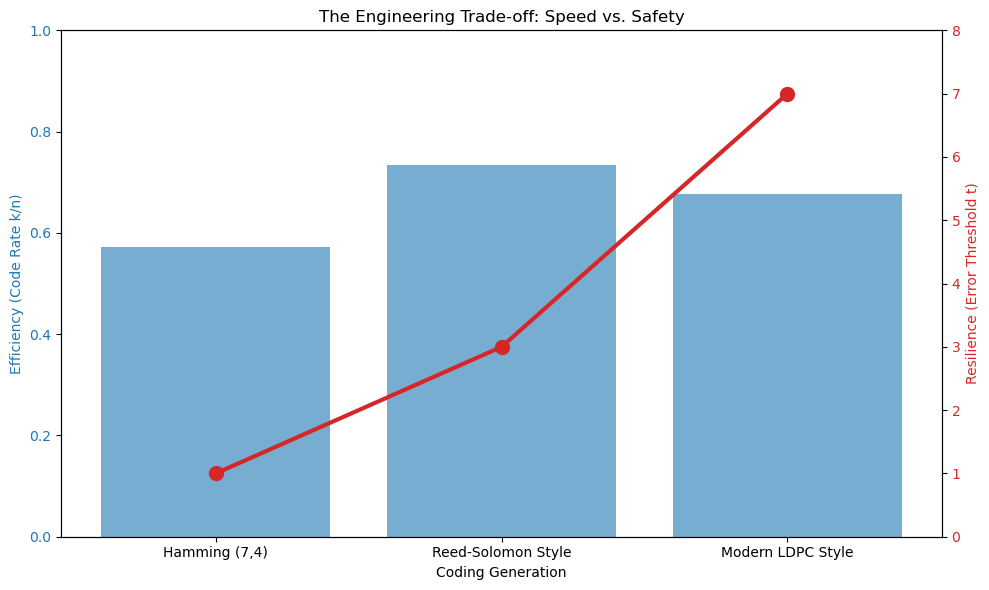

In [41]:
# We compare the Code Rate (Efficiency) vs. the Correction Power (Resilience)
codes = ['Hamming (7,4)', 'Reed-Solomon Style', 'Modern LDPC Style']
efficiency = [4/7, 11/15, 21/31] # k/n (Data bits / Total bits)
resilience = [1, 3, 7] # t (How many bits it can fix)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting Efficiency
color = 'tab:blue'
ax1.set_xlabel('Coding Generation')
ax1.set_ylabel('Efficiency (Code Rate k/n)', color=color)
ax1.bar(codes, efficiency, color=color, alpha=0.6, label='Efficiency (Higher is faster)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1)

# Plotting Resilience on the same chart
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Resilience (Error Threshold t)', color=color)
ax2.plot(codes, resilience, color=color, marker='o', linewidth=3, markersize=10, label='Resilience (Higher is tougher)')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 8)

plt.title('The Engineering Trade-off: Speed vs. Safety')
fig.tight_layout()
plt.show()

### 5.2 Efficiency vs. Protection (The Overhead)

Another thing I noticed during the analysis is that a stronger code is not always the best choice for every situation.

The Hamming (7,4) code is relatively efficient. It adds only three parity bits to four data bits, which gives a code rate of

$$
R = \frac{k}{n} = \frac{4}{7} \approx 0.57
$$

This means that about 57% of the transmitted bits contain actual data, while the rest are used for error correction. Because of this efficiency, Hamming codes are commonly used in places like computer memory where errors are rare but still need to be corrected quickly.

Modern error-correcting codes are much stronger, but they also introduce more redundancy. If a system needs a higher correction capability, for example

$$
t = 7
$$

then many more parity bits must be added to the message. This increases reliability but also increases the amount of bandwidth used.

The trade-off can be summarized as follows:

| Code Generation | Correction Power ($t$) | Typical Use Case | Cost (Redundancy) |
|-----------------|------------------------|------------------|-------------------|
| Hamming (7,4) | $t = 1$ bit | Internal computer memory (RAM) | Low (≈43%) |
| Reed–Solomon | $t \geq 3$ symbols | CDs, DVDs, QR codes | Medium |
| LDPC / 5G | $t \geq 7$ bits | Satellite, 5G, Wi-Fi | High |

---

### 5.3 Final Interpretation

From this analysis, I started to understand that the modern approach to error correction is not about completely avoiding noise. Instead, the goal is to design a code with a correction capability large enough to outperform the expected noise level.

In other words, engineers choose a value of

$$
t
$$

that is high enough for the environment where the system will operate.

For example, if I were designing a satellite communication system, I would not mind sending a heavier message with many parity bits if that meant the signal could still be recovered after traveling through space.

However, in a computer processor, errors are already extremely rare. In that situation, a lightweight code like Hamming (7,4) is usually the better choice because it provides protection without adding too much overhead.




## 6. Conclusion

In this project I tried to understand how data can still arrive correctly even when the channel that sends it is noisy. I started with the Hamming (7,4) code, which is one of the earliest practical error-correcting codes, and then looked at how more modern systems use larger and more powerful codes such as LDPC.

While working through the simulations and the theory, I started to see how ideas from linear algebra and probability are actually used in real communication systems. Things like XOR operations, matrices, and probability distributions are not just abstract math problems — they are part of the mechanisms that help protect data when it is transmitted.

### What I Learned

One thing that stood out to me was how the Hamming code can actually detect and correct an error. When I first saw XOR operations and matrix multiplication, they seemed mostly theoretical. But when implemented the Hamming code and ran the simulation, I could see how a flipped bit could be detected and corrected using the syndrome calculation. Seeing that happen in the program helped me understand how the math connects to the actual behavior of the system.

Another important idea I noticed is that there is always a trade-off between efficiency and protection. Error-correcting codes add extra bits to the message, which means more bandwidth or storage is required. For example, the Hamming (7,4) code sends 7 bits to protect 4 bits of data, which gives a code rate of

$$
R = \frac{4}{7}
$$

This means that some of the transmitted bits are used only for protection. Modern codes can correct more errors, but they also add even more redundancy.

I also found it interesting that the basic problem has stayed the same for a long time. Richard Hamming was trying to deal with errors in early computers in the 1940s, and today engineers still face the same issue when sending data through wireless networks, satellites, or fiber connections. The difference is that modern systems send much more data, so the error-correcting methods have become more advanced.

### Final Thoughts

Overall, this project helped me understand better how mathematics can be used to deal with errors in data. At the beginning, many of the concepts like matrices, XOR operations, and probability distributions felt mostly theoretical. But while working through the simulations and the examples, I started to see how these ideas actually work together to solve a real problem.

One thing that became clearer to me is how different areas of mathematics connect with each other. Linear algebra appears when we represent codes using matrices, combinatorics helps us think about how many possible error patterns can occur, and probability helps us estimate how likely those errors are. Seeing these topics interact made the theory feel more meaningful than when they are studied separately.

Another thing I realized is that mathematics is not only about exact answers, but also about building models that help us understand uncertain situations.

